# How far ahead is the best player?

A ranking tells you the order. It does not tell you the *gap*. Second place
might be a whisker behind, or it might be a chasm, and the table looks identical
either way.

So this chapter measures the gap properly. I look at where every player sits in
the distribution and ask how many standard deviations separate the best from
everyone else.

In [1]:
import warnings

import matplotlib
import pandas as pd

from gambeta import needs, tifo

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.figsize"] = (10, 5.5)

SAMPLE = "../data/sample"
ranking = pd.read_parquet(f"{SAMPLE}/ranking.parquet")
seasons = pd.read_parquet(f"{SAMPLE}/player_season_scored.parquet")
offsets = pd.read_parquet(f"{SAMPLE}/league_offsets.parquet")
keepers = pd.read_parquet(f"{SAMPLE}/keeper_ranking.parquet")

scores = ranking["score"].to_numpy(dtype=float)
mu, sigma = scores.mean(), scores.std(ddof=0)
print(f"players: {len(scores):,}")
print(f"mean:    {mu:.3f}")
print(f"sd:      {sigma:.3f}")

players: 5,508
mean:    0.000
sd:      0.574


## The distribution

Most players cluster near the middle. That is exactly what a composite of
twelve standardised requirements should do, because by construction the average
player scores about zero.

The interesting part is the right tail.

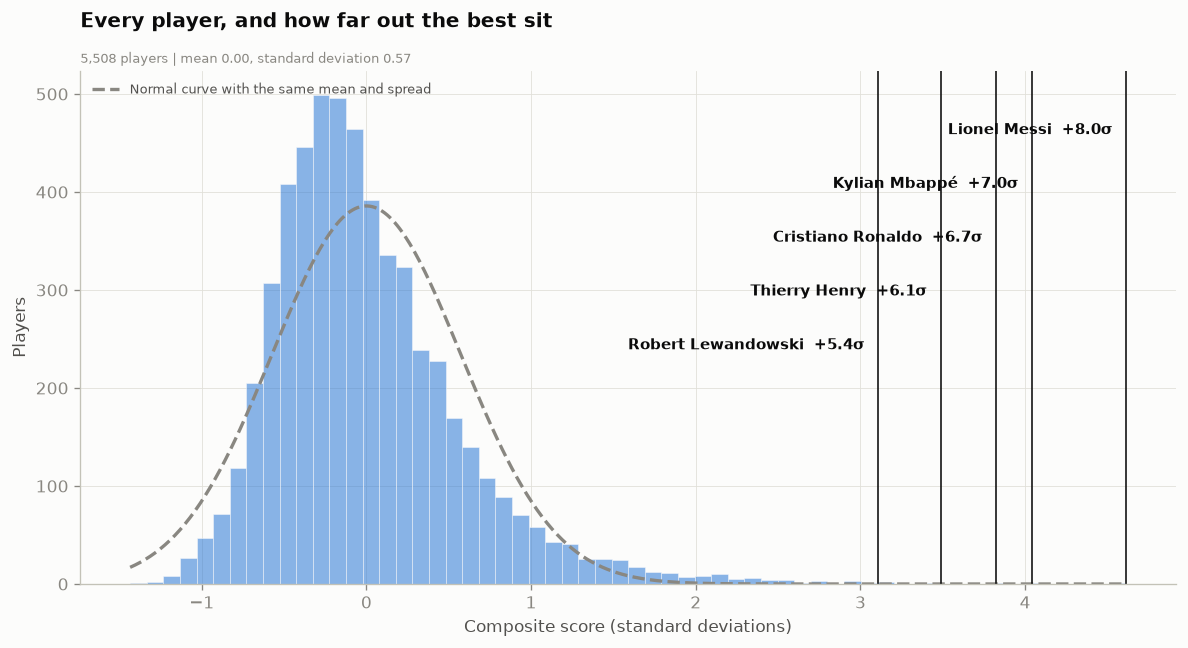

In [2]:
top5 = ranking.head(5)
fig = tifo.bell(
    ranking["score"],
    highlight=dict(zip(top5["player"], top5["score"], strict=True)),
    title="Every player, and how far out the best sit",
)

## Measuring the gap in sigma

A standard deviation is a natural yardstick here. It tells you how unusual a
score is *relative to the spread of the population itself*, so it travels across
different metrics and different eras without needing to be re-scaled.

In [3]:
head = ranking.head(10).copy()
head["sigma"] = (head["score"] - mu) / sigma
head[["player", "score", "sigma", "seasons"]].round(2)

,player,score,sigma,seasons
0,Lionel Messi,4.61,8.03,18
1,Kylian Mbappé,4.04,7.04,9
2,Cristiano Ronaldo,3.82,6.66,19
3,Thierry Henry,3.49,6.07,10
4,Robert Lewandowski,3.11,5.41,15
5,Harry Kane,3.02,5.27,11
6,Karim Benzema,2.98,5.18,17
7,Erling Haaland,2.93,5.10,6
8,Luis Suárez,2.92,5.09,12
9,Ruud van Nistelrooy,2.73,4.76,9


## The claim that should make you suspicious

Under a normal distribution, extreme values are astronomically rare. Let me take
that assumption completely seriously for a moment and see what it predicts.

In [4]:
from math import erfc, sqrt

best = ranking.iloc[0]
z = (best["score"] - mu) / sigma
p = erfc(z / sqrt(2)) / 2

print(f"{best['player']} sits {z:.2f} standard deviations above the mean.")
print(f"Under a normal distribution, P(score >= that) = {p:.3e}")
print(f"That is roughly 1 player in {1 / p:,.0f}.")
print(f"\nOur population is {len(scores):,} players.")

Lionel Messi sits 8.03 standard deviations above the mean.
Under a normal distribution, P(score >= that) = 4.682e-16
That is roughly 1 player in 2,135,911,132,049,805.

Our population is 5,508 players.


**Read that last line again.** Out of a pool of five and a half thousand
players, a normal distribution says the best one should not exist.

Taken at face value that says the best player should not exist. Which means
something is wrong with my assumption, not with the footballer.

## The assumption is wrong: the distribution is not normal

A normal distribution is symmetric. Football talent is not.

In [5]:
print(f"skewness: {pd.Series(scores).skew():.2f}   (0 = symmetric)")
print(f"kurtosis: {pd.Series(scores).kurtosis():.2f}   (0 = normal tails)")

for k in (2, 3, 4, 5, 6):
    expected = len(scores) * erfc(k / sqrt(2)) / 2
    actual = int((scores > mu + k * sigma).sum())
    print(f"  beyond {k} sigma: normal predicts {expected:8.2f}, we observe {actual:4d}")

skewness: 1.39   (0 = symmetric)
kurtosis: 4.12   (0 = normal tails)
  beyond 2 sigma: normal predicts   125.31, we observe  230
  beyond 3 sigma: normal predicts     7.44, we observe   80
  beyond 4 sigma: normal predicts     0.17, we observe   28
  beyond 5 sigma: normal predicts     0.00, we observe   10
  beyond 6 sigma: normal predicts     0.00, we observe    4


The right tail is **much fatter than normal**. At three, four and five sigma
there are far more players than a bell curve allows for.

This is not a defect in the data. It is a real property of elite performance and
it has a name: a heavy-tailed distribution. Ability that compounds, because
better players get better coaching, better teammates, more minutes and better
opponents to learn from, does not produce a symmetric bell. It produces a long
right tail where a handful of people sit far beyond everyone else.

**So the honest statement is not "Messi is a 5.9-sigma player" as though that
were a probability.** It is this: under the wrong model he is impossible, and
the fact that he exists is evidence the model is wrong.

## The gap between first and second

Sigma is still useful for comparison, as long as I use it as a ruler and not as
a probability.

In [6]:
gaps = ranking.head(6)[["player", "score"]].copy()
gaps["sigma"] = (gaps["score"] - mu) / sigma
gaps["gap_to_next"] = gaps["score"].diff(-1)
gaps.round(2)

,player,score,sigma,gap_to_next
0,Lionel Messi,4.61,8.03,0.57
1,Kylian Mbappé,4.04,7.04,0.22
2,Cristiano Ronaldo,3.82,6.66,0.34
3,Thierry Henry,3.49,6.07,0.38
4,Robert Lewandowski,3.11,5.41,0.08
5,Harry Kane,3.02,5.27,NaN


In [7]:
first, second = ranking.iloc[0], ranking.iloc[1]
gap_sigma = (first["score"] - second["score"]) / sigma
print(f"{first['player']} to {second['player']}: {gap_sigma:.2f} sigma")
print(
    f"{second['player']} to {ranking.iloc[5]['player']}: "
    f"{(second['score'] - ranking.iloc[5]['score']) / sigma:.2f} sigma "
    f"(covering four players)"
)

Lionel Messi to Kylian Mbappé: 0.99 sigma
Kylian Mbappé to Harry Kane: 1.77 sigma (covering four players)


## The result, stated in players rather than decimals

A lead of 0.57 means nothing on its own. The way to actually feel it is to take
the gap between first and second, lay that same distance below someone else, and
see **who you land on**.

In [8]:
q = ranking[ranking["qualified"]].reset_index(drop=True)
lead = q.loc[0, "score"] - q.loc[1, "score"]


def ordinal(n: int) -> str:
    suffix = "th" if 10 <= n % 100 <= 20 else {1: "st", 2: "nd", 3: "rd"}.get(n % 10, "th")
    return f"{n}{suffix}"


def named(i: int) -> str:
    return f"{q.loc[i, 'player']} ({ordinal(i + 1)})"


def same_distance_below(rank: int) -> int:
    """Index of the player sitting as far below `rank` as second sits below first."""
    target = q.loc[rank, "score"] - lead
    return int((q["score"] - target).abs().idxmin())


below_second = same_distance_below(1)
below_third = same_distance_below(2)

print(
    f"{named(1)} is as close to {named(0)}\n"
    f"  as {named(below_second)} is to {named(1)},\n"
    f"  or {named(below_third)} is to {named(2)}."
)
print(f"\n(every one of those gaps is {lead:.2f}, or {lead / sigma:.1f} sigma)")

Kylian Mbappé (2nd) is as close to Lionel Messi (1st)
  as Thierry Henry (4th) is to Kylian Mbappé (2nd),
  or Robert Lewandowski (5th) is to Cristiano Ronaldo (3rd).

(every one of those gaps is 0.57, or 1.0 sigma)


Read that again, because it is the finding of this chapter. The distance from
second place to first is not a photo finish. It is the same distance that
separates second place from a player **two** positions further down, and third
place from one **two** positions down as well.

Here is one more way to put it. Compare the lead at the top against the entire
spread of the chasing pack.

In [9]:
chasers = q.loc[1, "score"] - q.loc[7, "score"]
print(f"first to second:  {lead:.2f}")
print(f"second to eighth: {chasers:.2f}   (covering six players)")
print()
print(
    "The lead of one player over the next is larger than the spread"
    if lead > chasers
    else "The chasing pack is more spread out than the lead"
)
print("across the whole of the chasing pack.")

first to second:  0.57
second to eighth: 1.11   (covering six players)

The chasing pack is more spread out than the lead
across the whole of the chasing pack.


The top of this list is not a tight race followed by a drop-off. It is one
player clear, and then a cluster.

## Where each requirement puts the best player

The composite hides which requirements the gap actually comes from. Breaking it
out shows you whether the dominance is broad or narrow.

In [10]:
keys = [r.key for r in needs.OUTFIELD if r.key in ranking.columns]
profile = (
    ranking.set_index("player").loc[[ranking.iloc[0]["player"], ranking.iloc[1]["player"]], keys].T
)
profile.columns = [f"{c} (sigma)" for c in profile.columns]
profile.round(2)

,Lionel Messi (sigma),Kylian Mbappé (sigma)
scoring,5.31,5.43
creation,4.62,2.55
finishing,1.12,0.91
threat,4.87,4.75
team_share,3.57,3.38
availability,1.43,0.27
reliability,3.33,1.90
longevity,3.92,0.95
consistency,7.09,6.55
discipline,1.35,0.51


## What would change my mind

- **A different composite.** These sigma figures are for the equal-weighted
  composite. Reweight the requirements and the gap changes with them.
- **The population defines the yardstick.** Sigma is measured against 5,508
  players who cleared the minutes threshold in the Big 5. Lower that threshold
  to let fringe players in, or add a competition, and the standard deviation
  moves, which moves everybody's sigma.
- **Heavy tails cut both ways.** If the distribution is not normal, then sigma
  is a descriptive ruler and nothing more. Any sentence of the form "this is a
  one-in-N-billion player" is misusing it, including one I could very easily
  have written above.